In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

import importlib

import tensorboard
%load_ext tensorboard

import math

from torch.utils.tensorboard import SummaryWriter
import datetime
import time

import os, sys
module_path = os.path.abspath(os.path.join('..', "source"))
if module_path not in sys.path:
    sys.path.append(module_path)

import pbr_dataset
import models

import torchmetrics
import flip_loss

from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

## Tensorboard
This command gets you tensorboard with all the metrics and data. Run it in a command line in the notebook directory if you want it on its own tab. 
### Warning
I would recommend just running the command in a command prompt because I don't know how to close the server from a notebook.

In [2]:
tensorboard.notebook.list()

Known TensorBoard instances:
  - port 6006: logdir ../experiments/pbr_compression (started 0:05:54 ago; pid 23368)


tensorboard --logdir ../experiments/pbr_compression --samples_per_plugin images=500

In [14]:
tensorboard.notebook.start("--logdir ../experiments/pbr_compression --samples_per_plugin images=500")

## Loading the PBR textures
For now I'm just going to assume that each pbr material has a texture folder and there are three textures named 'arm.jpg', 'albedo.jpg' and 'normal.jpg'.

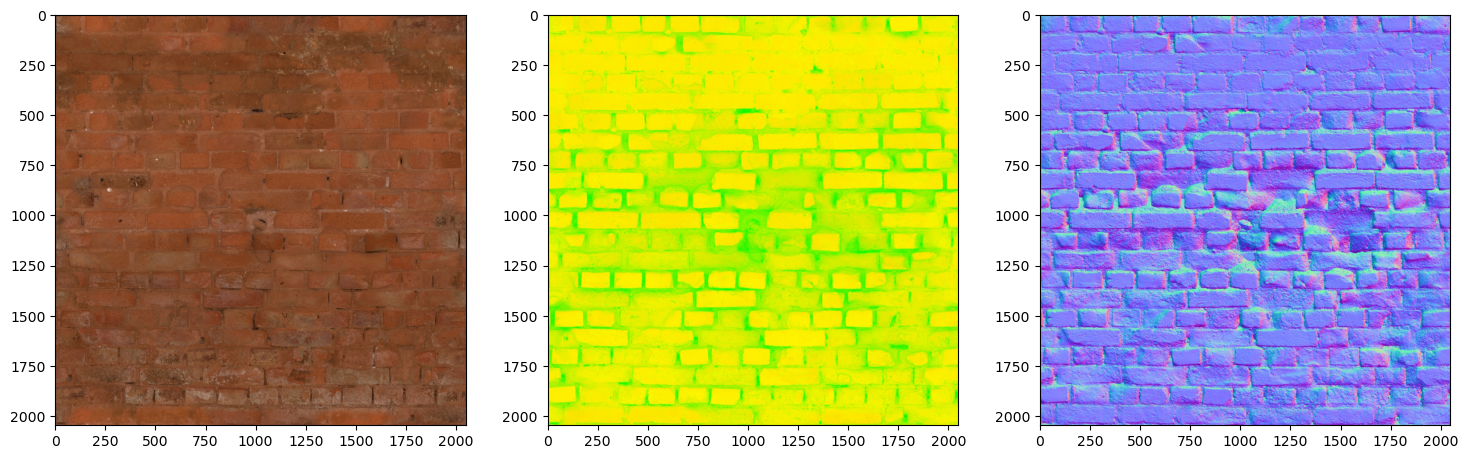

In [2]:
materials_path = "../assets/materials/"
material_name = "broken_brick_wall"
material_textures_path = materials_path + material_name + "/textures/"
ext = ".jpg"

albedo = Image.open(material_textures_path + "albedo" + ext).convert("RGB")
arm = Image.open(material_textures_path + "arm" + ext).convert("RGB")
normal = Image.open(material_textures_path + "normal" + ext).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(albedo)
axes[1].imshow(arm)
axes[2].imshow(normal)

plt.show()

# Metrics

In [3]:
def psnr(y_pred, y, data_range):
    dim = tuple(range(1, y.ndim))
    mse_error = torch.pow(y_pred - y.view_as(y_pred), 2).mean(dim=dim)
    val = torch.sum(10.0 * torch.log10(data_range**2 / (mse_error + 1e-10))).cpu().item()

    val = val / y.shape[0]
    
    return val

# Training Loop

In [4]:
def test_model(model, dataset, loss_fn, albedo_data, arm_data, normal_data):
    model.eval()

    with torch.no_grad():
        test_pred, net_input = model(dataset.input_features_tensor.reshape(1, model.resolution, model.resolution, 2))
        test_loss = loss_fn(test_pred, dataset.output_features_tensor)

    #print(test_pred.shape)
    #print(test_pred)
    
    
    test_pred_features = test_pred.cpu().view((dataset.sidelength, dataset.sidelength, -1)).detach()
    
    #print(test_pred_features.shape)
    
    albedo_pred_raw = test_pred_features[..., :3]
    arm_pred_raw = test_pred_features[..., 3:6]
    normal_pred_raw = test_pred_features[..., 6:]        
    
    albedo_pred = np.clip(albedo_pred_raw.numpy(), 0.0, 1.0)
    arm_pred = np.clip(arm_pred_raw.numpy(), 0.0, 1.0)
    normal_pred = np.clip(normal_pred_raw.numpy(), 0.0, 1.0)

    NCHW_shape = (1, 3, albedo_pred.shape[0], albedo_pred.shape[0])
    HWC_shape = (albedo_pred.shape[0], albedo_pred.shape[0], 1)

    pixels_per_degree = (0.7 * 3840 / 0.7) * np.pi / 180
    qc = 0.7
    qf = 0.5
    pc = 0.4
    pt = 0.95
    eps = 1e-15
    
    albedo_flip = flip_loss.compute_ldrflip(albedo_pred_raw.cuda().detach().permute(2, 0, 1).reshape(NCHW_shape), 
                                            albedo_data.cuda().detach().permute(2, 0, 1).reshape(NCHW_shape),
                                            pixels_per_degree, qc, qf, pc, pt, eps)
    arm_flip = flip_loss.compute_ldrflip(arm_pred_raw.cuda().detach().permute(2, 0, 1).reshape(NCHW_shape), 
                                         arm_data.cuda().detach().permute(2, 0, 1).reshape(NCHW_shape),
                                            pixels_per_degree, qc, qf, pc, pt, eps)
    normal_flip = flip_loss.compute_ldrflip(normal_pred_raw.cuda().detach().permute(2, 0, 1).reshape(NCHW_shape), 
                                            normal_data.cuda().detach().permute(2, 0, 1).reshape(NCHW_shape),
                                            pixels_per_degree, qc, qf, pc, pt, eps)

    albedo_flip = albedo_flip.cpu().permute(0, 2, 3, 1).reshape(HWC_shape)
    arm_flip = arm_flip.cpu().permute(0, 2, 3, 1).reshape(HWC_shape)
    normal_flip = normal_flip.cpu().permute(0, 2, 3, 1).reshape(HWC_shape)

    #neural_tex = model.neu_tex.pixel_tex.cpu().detach().permute(0, 3, 2, 1).reshape((model.resolution, model.resolution, model.neu_tex.pixel_embedding_channels))
    
    fig, axes = plt.subplots(3, 3, figsize=(18,18))
    axes[0, 0].imshow(albedo_data)
    axes[0, 1].imshow(albedo_pred)
    axes[0, 2].imshow(albedo_flip)
    axes[1, 0].imshow(arm_data)
    axes[1, 1].imshow(arm_pred)
    axes[1, 2].imshow(arm_flip)
    axes[2, 0].imshow(normal_data)
    axes[2, 1].imshow(normal_pred)
    axes[2, 2].imshow(normal_flip)

    plt.show()

    #fig, ax = plt.subplots(figsize=(6, 6))
    #ax.imshow(np.clip(neural_tex.numpy(), 0, 1) * (1/10e-4))

    #plt.show()

    #print(net_input.shape)
    #print(net_input)

    return albedo_pred_raw, arm_pred_raw, normal_pred_raw, albedo_flip, arm_flip, normal_flip

def output_test_data(model, albedo_pred, arm_pred, normal_pred, albedo_flip, arm_flip, normal_flip, 
                     albedo_data, arm_data, normal_data, current_epoch_arg):
    writer.add_scalar('psnr/albedo', psnr(albedo_pred, albedo_data, 1.0), current_epoch_arg)
    writer.add_scalar('psnr/arm', psnr(arm_pred, arm_data, 1.0), current_epoch_arg)
    writer.add_scalar('psnr/normal', psnr(normal_pred, normal_data, 1.0), current_epoch_arg)

    # ssim throws an error if the sidelength is to small   
    run_ssim = albedo_pred.shape[0] >= 256

    if run_ssim:
        NCHW_shape = (1, 3, albedo_pred.shape[0], albedo_pred.shape[0])
    
        msssim_albedo = torchmetrics.functional.image.multiscale_structural_similarity_index_measure(
                        albedo_pred.detach().reshape(NCHW_shape), albedo_data.detach().reshape(NCHW_shape),
                        data_range=1.0)

        msssim_arm =    torchmetrics.functional.image.multiscale_structural_similarity_index_measure(
                        arm_pred.reshape(NCHW_shape), arm_data.reshape(NCHW_shape),
                        data_range=1.0)

        msssim_normal = torchmetrics.functional.image.multiscale_structural_similarity_index_measure(
                        normal_pred.reshape(NCHW_shape), normal_data.reshape(NCHW_shape),
                        data_range=1.0)

        writer.add_scalar('ms-ssim/albedo', msssim_albedo, current_epoch_arg)
        writer.add_scalar('ms-ssim/arm', msssim_arm, current_epoch_arg)
        writer.add_scalar('ms-ssim/normal', msssim_normal, current_epoch_arg)
    
    albedo_image = np.clip(albedo_pred.numpy(), 0.0, 1.0)
    arm_image = np.clip(arm_pred.numpy(), 0.0, 1.0)
    normal_image = np.clip(normal_pred.numpy(), 0.0, 1.0)
    
    writer.add_image('image/albedo', albedo_image, current_epoch_arg, dataformats='HWC')
    writer.add_image('image/arm', arm_image, current_epoch_arg, dataformats='HWC')
    writer.add_image('image/normal', normal_image, current_epoch_arg, dataformats='HWC')

    flip_albedo_image = np.clip(albedo_flip.numpy(), 0.0, 1.0)
    flip_arm_image = np.clip(arm_flip.numpy(), 0.0, 1.0)
    flip_normal_image = np.clip(normal_flip.numpy(), 0.0, 1.0)

    fig_albedo_flip, ax_albedo_flip = plt.subplots(figsize=(10, 10))
    ax_albedo_flip.imshow(flip_albedo_image)
    fig_arm_flip, ax_arm_flip = plt.subplots(figsize=(10, 10))
    ax_arm_flip.imshow(flip_arm_image)
    fig_normal_flip, ax_normal_flip = plt.subplots(figsize=(10, 10))
    ax_normal_flip.imshow(flip_normal_image)

    writer.add_figure('flip/albedo', fig_albedo_flip, current_epoch_arg)
    writer.add_figure('flip/arm', fig_arm_flip, current_epoch_arg)
    writer.add_figure('flip/normal', fig_normal_flip, current_epoch_arg)

    for i, layer in enumerate(model.siren_net.net):
        writer.add_histogram(f"layer{i}/weights", layer.linear.weight, current_epoch_arg)
        writer.add_histogram(f"layer{i}/biases", layer.linear.bias, current_epoch_arg)

def training_loop(model, optimizer, dataloader, loss_fn, num_epochs, summary_interval):
    dataset = dataloader.dataset
    
    data_size = len(dataset)

    input_features = dataset.input_features_tensor.cpu().detach()
    output_features = dataset.output_features_tensor.cpu().view((dataset.sidelength, dataset.sidelength, -1)).detach()

    albedo_data = output_features[..., :3]
    arm_data = output_features[..., 3:6]
    normal_data = output_features[..., 6:]
    
    for epoch_idx in range(num_epochs):        
        current_epoch_loc = current_epoch + epoch_idx
        
        clear_output(wait=True)
        
        albedo_pred, arm_pred, normal_pred, albedo_flip, arm_flip, normal_flip = test_model(model, dataset, loss_fn, albedo_data, arm_data, normal_data)

        if epoch_idx != 0 or current_epoch_loc == 0:
            output_test_data(model, albedo_pred, arm_pred, normal_pred, albedo_flip, arm_flip, 
                             normal_flip, albedo_data, arm_data, normal_data, current_epoch_loc)

        print(f"epoch: {current_epoch_loc:>3d}")
        
        model.train()
        for batch_idx, (input_tensor, ground_truth) in enumerate(dataloader):
            pred, net_input = model(input_tensor.reshape((1, 1, -1, 2)))
            loss = loss_fn(pred, ground_truth)

            writer.add_scalar('loss', loss.item(), batch_idx + len(dataloader) * (current_epoch_loc))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if batch_idx % summary_interval == 0:
                print(f"loss: {loss.item():>7f} [{(batch_idx * dataloader.batch_size + len(input_tensor)):>5d}/{data_size:>5d}]")

        writer.flush()

    clear_output(wait=True)

    albedo_pred, arm_pred, normal_pred, albedo_flip, arm_flip, normal_flip = test_model(model, dataset, loss_fn, albedo_data, arm_data, normal_data)
    output_test_data(model, albedo_pred, arm_pred, normal_pred, albedo_flip, arm_flip, 
                     normal_flip, albedo_data, arm_data, normal_data, current_epoch + num_epochs)
    writer.flush()

    print(f"epoch: {(current_epoch + num_epochs):>3d}")

In [38]:
importlib.reload(models)
importlib.reload(pbr_dataset)

model_test = models.BCNeuTex(512, 4, 6, 2)

print(test_model.block_sidelength)

del test_sample
del model_test
del test_model

4


NameError: name 'test_sample' is not defined

In [5]:
importlib.reload(models)
importlib.reload(pbr_dataset)

if 'writer' in globals():
    writer.close()
    del writer
    
writer = SummaryWriter("../experiments/pbr_compression/bc_neutex_siren" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

hidden_features = 64
hidden_layers = 3
first_omega = 20
hidden_omega = 15
sidelength = 1024
block_sidelength = 4
block_embedding_channels = 8
pixel_embedding_channels = 3
batch_size = 512
texture_sample_mode = 'nearest'

model = models.SirenBCTex(sidelength, block_sidelength, block_embedding_channels, pixel_embedding_channels,
                          out_features=3*3, hidden_features=hidden_features, hidden_layers=hidden_layers, 
                           mode=texture_sample_mode, first_omega_0=first_omega, hidden_omega_0=hidden_omega).cuda()

dataset = pbr_dataset.PBRDataset(albedo, arm, normal, sidelength=sidelength)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

#writer.add_graph(model.siren_net, dataset.input_features_tensor)
writer.add_text("model info", f"sidelength: {sidelength}\ntexture sample mode: {texture_sample_mode}\nblock sidelength: {model.neu_tex.block_sidelength}\nblock embedding channels: {block_embedding_channels}\npixel embedding channels: {pixel_embedding_channels}\nbatch size: {batch_size}\nhidden features: {hidden_features}\nhidden layers: {hidden_layers}\nfirst omega: {first_omega}\nhidden omega: {hidden_omega}")

current_epoch = 0

C:\Users\avree\miniforge3\envs\ml\lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\bld\libtorch_1753839109265\work\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


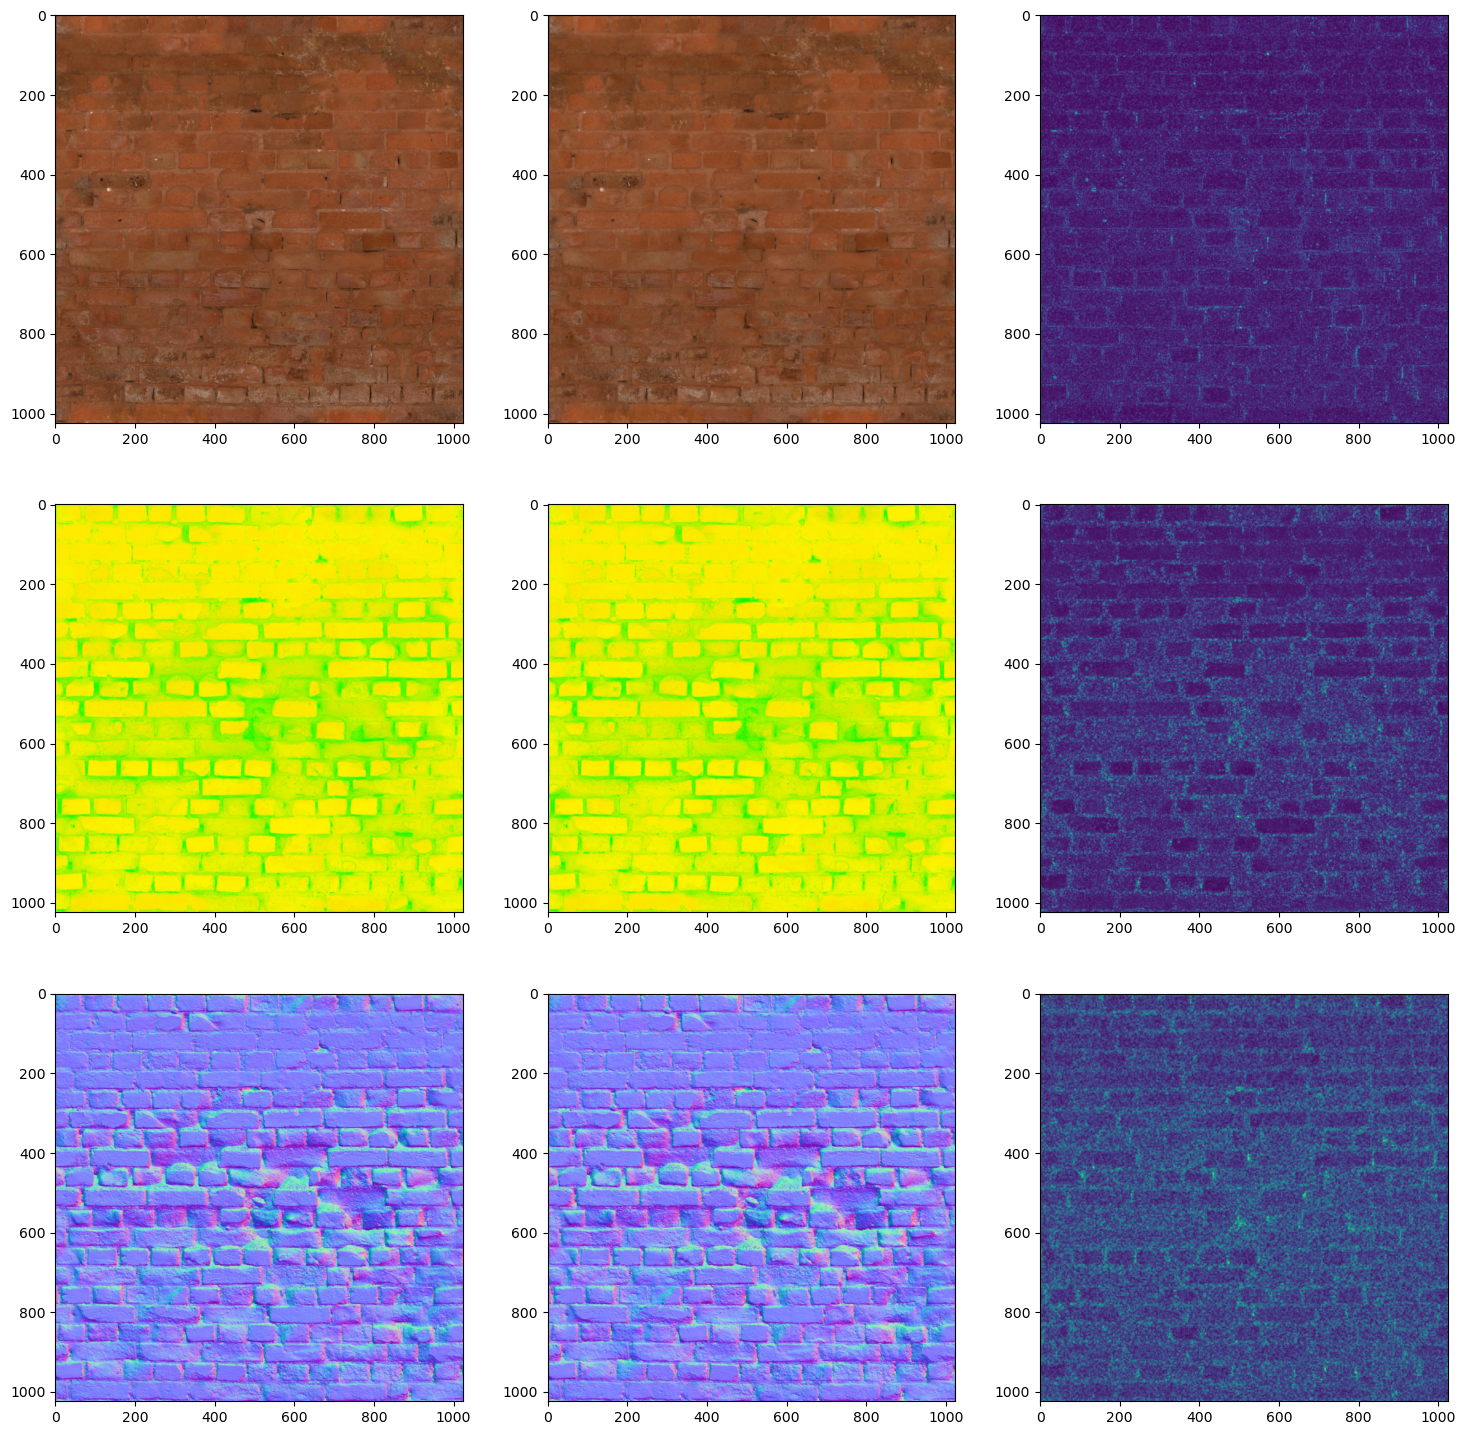

epoch:  20


In [6]:
optimizer = torch.optim.Adam(lr=1e-4, params=model.parameters())

loss_fn = torch.nn.L1Loss()

num_epochs = 20

training_loop(model, optimizer, dataloader, loss_fn, num_epochs, 20)
current_epoch = current_epoch + num_epochs